In [ ]:
# Sales Data Analysis with Python

## Business Objective

This project analyzes historical sales transactions to identify trends across time, countries, product lines, customers, and order statuses. The goal is to provide insights that could support sales and marketing decisions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("sales_data_sample.csv", encoding="latin1")

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head()

Rows: 2,823
Columns: 25


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,Motorcycles,95,S10_1678,Land of Toys Inc.,2125557818,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,Motorcycles,95,S10_1678,Lyon Souveniers,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,Motorcycles,95,S10_1678,Toys4GrownUps.com,6265557265,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,Motorcycles,95,S10_1678,Corporate Gift Ideas Co.,6505551386,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [ ]:
## 1. Data Inspection and Validation

Before analysis, the dataset is examined for incorrect data types, missing values, duplicate records, and invalid values.

In [4]:
df.info

<bound method DataFrame.info of       ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER    SALES  \
0           10107               30      95.70                2  2871.00   
1           10121               34      81.35                5  2765.90   
2           10134               41      94.74                2  3884.34   
3           10145               45      83.26                6  3746.70   
4           10159               49     100.00               14  5205.27   
...           ...              ...        ...              ...      ...   
2818        10350               20     100.00               15  2244.40   
2819        10373               29     100.00                1  3978.51   
2820        10386               43     100.00                4  5417.57   
2821        10397               34      62.24                1  2116.16   
2822        10414               47      65.52                9  3079.44   

            ORDERDATE    STATUS  QTR_ID  MONTH_ID  YEAR_ID  PRODUCT

In [5]:
missing_values = (df.isnull().sum().sort_values(ascending=False).to_frame("Missing Values"))
missing_values["Missing %"] = (
    missing_values["Missing Values"] / len(df) * 100
).round(2)

missing_values[missing_values["Missing Values"] > 0]


,Missing Values,Missing %
ADDRESSLINE2,2521,89.30
STATE,1486,52.64
TERRITORY,1074,38.04
POSTALCODE,76,2.69


In [6]:
print(f"Duplicate Rows: {df.duplicated().sum()}")

Duplicate Rows: 0


In [7]:
Sales_by_country = df.groupby('COUNTRY')['SALES'].sum().sort_values(ascending= False)
Sales_by_country

COUNTRY
USA            3627982.83
Spain          1215686.92
France         1110916.52
Australia       630623.10
UK              478880.46
Italy           374674.31
Finland         329581.91
Norway          307463.70
Singapore       288488.41
Denmark         245637.15
Canada          224078.56
Germany         220472.09
Sweden          210014.21
Austria         202062.53
Japan           188167.81
Switzerland     117713.56
Belgium         108412.62
Philippines      94015.73
Ireland          57756.43
Name: SALES, dtype: float64

In [8]:
df["ORDERDATE"] = pd.to_datetime(
    df["ORDERDATE"],
    errors="coerce"
)

print(f"Invalid dates: {df['ORDERDATE'].isnull().sum()}")
print(f"First order: {df['ORDERDATE'].min().date()}")
print(f"Last order: {df['ORDERDATE'].max().date()}")

Invalid dates: 0
First order: 2003-01-06
Last order: 2005-05-31


In [ ]:
### Missing-Value Findings

Missing values were found only in optional geographic and address fields
    . These records were retained because removing them would unnecessarily discard valid sales transactions
    . The missing fields are not required for the main sales analysis.

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df[["QUANTITYORDERED", "PRICEEACH", "SALES", "MSRP"]].describe().round(2)

,QUANTITYORDERED,PRICEEACH,SALES,MSRP
count,2823.00,2823.00,2823.00,2823.00
mean,35.09,83.66,3553.89,100.72
std,9.74,20.17,1841.87,40.19
min,6.00,26.88,482.13,33.00
25%,27.00,68.86,2203.43,68.00
50%,35.00,95.70,3184.80,99.00
75%,43.00,100.00,4508.00,124.00
max,97.00,100.00,14082.80,214.00


In [11]:
df["CALCULATED_SALES"] = df["QUANTITYORDERED"] * df["PRICEEACH"]

In [12]:
df["SALES_DIFFERENCE"] = (df["SALES"] - df["CALCULATED_SALES"]).abs()
(df["SALES_DIFFERENCE"] > 0.01).sum()

np.int64(1304)

In [13]:
df.loc[
    df["SALES_DIFFERENCE"] > 0.01,
    ["QUANTITYORDERED", "PRICEEACH", "SALES", "CALCULATED_SALES", "SALES_DIFFERENCE"]
].head(10)

,QUANTITYORDERED,PRICEEACH,SALES,CALCULATED_SALES,SALES_DIFFERENCE
4,49,100.0,5205.27,4900.0,305.27
7,48,100.0,5512.32,4800.0,712.32
9,41,100.0,4708.44,4100.0,608.44
10,37,100.0,3965.66,3700.0,265.66
11,23,100.0,2333.12,2300.0,33.12
12,28,100.0,3188.64,2800.0,388.64
13,34,100.0,3676.76,3400.0,276.76
15,36,100.0,4099.68,3600.0,499.68
16,23,100.0,2597.39,2300.0,297.39
17,41,100.0,4394.38,4100.0,294.38


In [ ]:
### Sales Validation Note

A validation check compared `SALES` with `QUANTITYORDERED × PRICEEACH`. Differences were found in 1,304 records, primaril
y where `PRICEEACH` equals $100. This suggests that `PRICEEACH` may be capped at $100 or transformed in the source dataset.

Because the original pricing logic is unavailable, the provided `SALES` values were retained for analys
    is. The temporary validation columns were removed.

In [14]:
df.drop(columns=["CALCULATED_SALES", "SALES_DIFFERENCE"], inplace=True)

In [15]:
df["YEARMONTH"]=df["ORDERDATE"].dt.to_period("M")

In [16]:
df[["ORDERDATE","YEARMONTH"]].head()

,ORDERDATE,YEARMONTH
0,2003-02-24,2003-02
1,2003-05-07,2003-05
2,2003-07-01,2003-07
3,2003-08-25,2003-08
4,2003-10-10,2003-10


In [17]:
monthly_sales = df.groupby("YEARMONTH")["SALES"].sum()


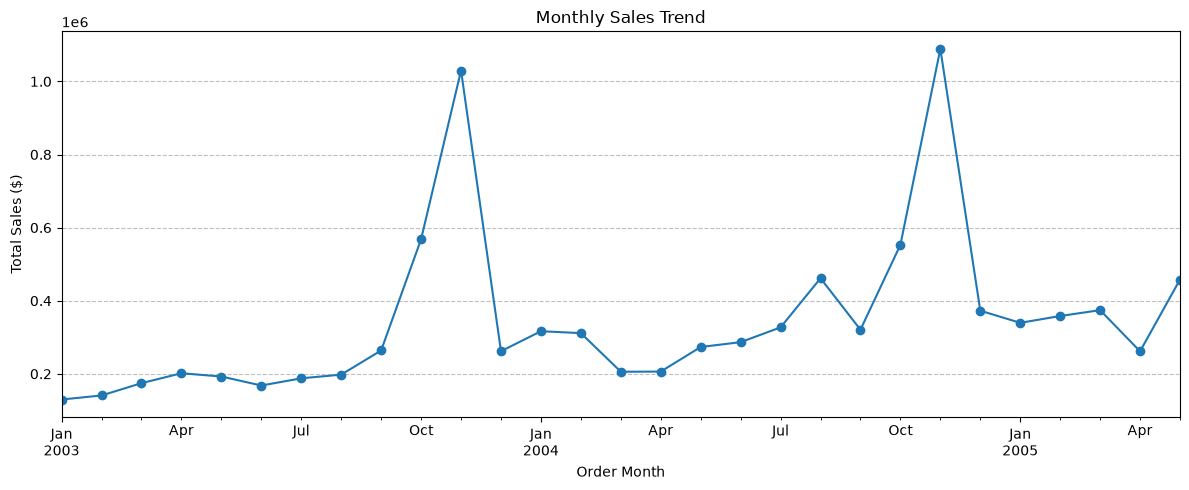

In [18]:
monthly_sales.plot(kind="line", figsize=(12, 5), marker="o")
plt.ylabel("Total Sales ($)")
plt.title ("Monthly Sales Trend")
plt.xlabel ("Order Month")
plt.grid(axis="y", linestyle="--", alpha=0.8)
plt.tight_layout()

In [19]:
monthly_sales.idxmax()

Period('2004-11', 'M')

In [20]:
monthly_sales.max()

np.float64(1089048.01)

In [ ]:
### Monthly Sales Insight

Monthly sales peaked in November 2004 at approximately $1.09 million. The chart also shows strong November performance across the availabl
e full years, suggesting a possible seasonal increase in demand during the holiday period.

Because the dataset contains only two complete years and ends in May 2005, this pattern should be treated as an indication rather than pr
oof of long-term seasonality.

In [21]:
total_sales=df['SALES'].sum()

In [22]:
print(f"Total Sales: ${total_sales:,.2f}")

Total Sales: $10,032,628.85


In [23]:
Sales_by_Year=df.groupby('YEAR_ID')['SALES']. sum().sort_values (ascending= False)
Sales_by_Year

YEAR_ID
2004    4724162.60
2003    3516979.54
2005    1791486.71
Name: SALES, dtype: float64

In [24]:
total_orders = df["ORDERNUMBER"].nunique()

In [25]:
print(f"Total Orders: {total_orders:,}")

Total Orders: 307


In [26]:
average_order_value=total_sales/total_orders

In [27]:
print(f"Average Order Value: ${average_order_value:,.2f}")

Average Order Value: $32,679.57


In [28]:
total_customers = df["CUSTOMERNAME"].nunique()

In [104]:
print(f"Total Customers: {total_customers:,}")

Total Customers: 92


In [29]:
total_units=df['QUANTITYORDERED'].sum()

In [30]:
print(f"Total Units Sold: {total_units:,}")

Total Units Sold: 99,067


In [31]:
product_sales=df.groupby('PRODUCTLINE')['SALES'].sum().sort_values (ascending= False)
product_sales

PRODUCTLINE
Classic Cars        3919615.66
Vintage Cars        1903150.84
Motorcycles         1166388.34
Trucks and Buses    1127789.84
Planes               975003.57
Ships                714437.13
Trains               226243.47
Name: SALES, dtype: float64

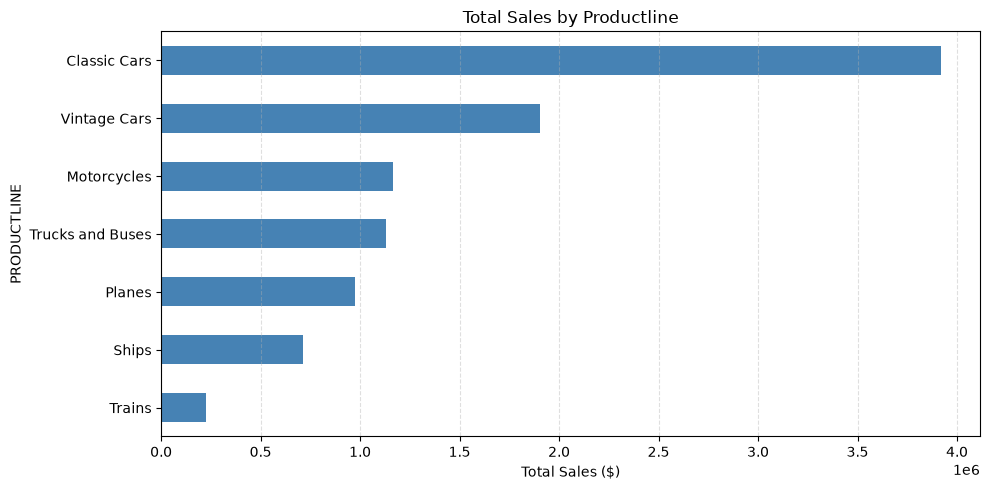

In [48]:
product_sales.sort_values().plot(kind="barh", figsize=(10, 5), color="steelblue")
plt.title('Total Sales by Productline')
plt.xlabel ('Total Sales ($)')
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()

In [52]:
top_product_share= product_sales.iloc[0]/total_sales * 100

In [53]:
print(f'Top Product Line Share: {top_product_share:.1f}%')

Top Product Line Share: 39.1%


In [ ]:
### Product-Line Insight

Classic Cars was the highest-performing product line, generating approximately $3.92 million and accounting for about 39.1% of total sales
    . Vintage Cars ranked second at approximately $1.90 million.

The company should protect inventory and marketing support for Classic Cars while investigating opportunities to impr
    ove lower-performing product lines such as Trains.

In [57]:
country_sales=df.groupby('COUNTRY')['SALES'].sum().sort_values(ascending=False)
country_sales

COUNTRY
USA            3627982.83
Spain          1215686.92
France         1110916.52
Australia       630623.10
UK              478880.46
Italy           374674.31
Finland         329581.91
Norway          307463.70
Singapore       288488.41
Denmark         245637.15
Canada          224078.56
Germany         220472.09
Sweden          210014.21
Austria         202062.53
Japan           188167.81
Switzerland     117713.56
Belgium         108412.62
Philippines      94015.73
Ireland          57756.43
Name: SALES, dtype: float64

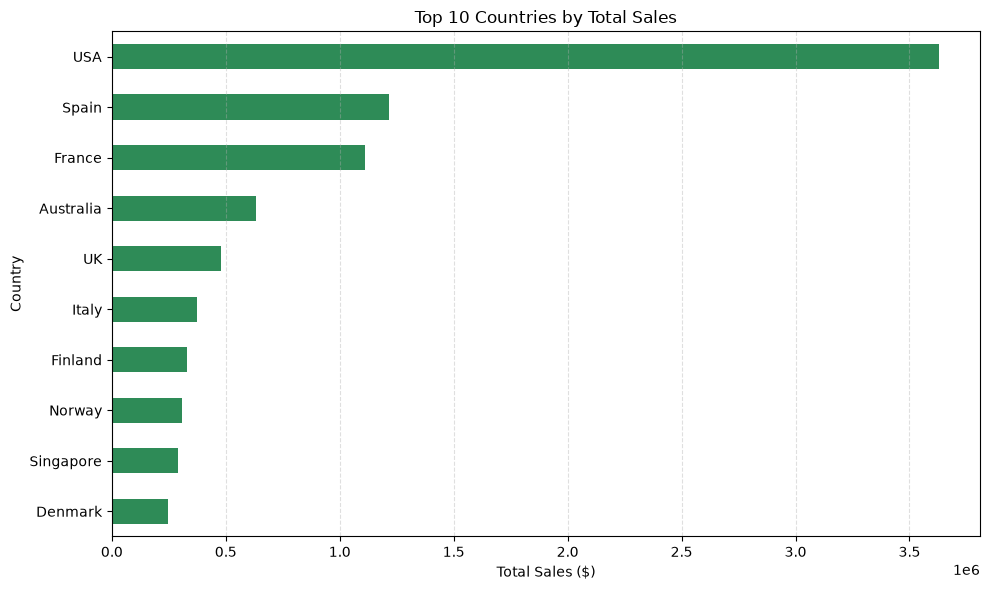

In [64]:
country_sales.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6),
    color="seagreen"
)

plt.title("Top 10 Countries by Total Sales")
plt.xlabel("Total Sales ($)")
plt.ylabel("Country")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [65]:
usa_sales_share = country_sales.loc["USA"] / total_sales * 100

print(f"USA Sales: ${country_sales.loc['USA']:,.2f}")
print(f"USA Share of Total Sales: {usa_sales_share:.1f}%")

USA Sales: $3,627,982.83
USA Share of Total Sales: 36.2%


In [ ]:
### Country Sales Insight

The USA was the largest market, generating approximately $3.63 million and accounting for about 36.2% of total sales. Spain and France ranked second and third.

The company should protect its strong US customer base while reducing geographic dependence by investigating growth opportunities in other established markets such as Spain and France.%")

In [66]:
customer_summary = (df.groupby("CUSTOMERNAME").agg
          (TOTAL_SALES=("SALES", "sum"),
          TOTAL_ORDERS=("ORDERNUMBER", "nunique"))
      .sort_values("TOTAL_SALES", ascending=False))

customer_summary.head(10)

,TOTAL_SALES,TOTAL_ORDERS
CUSTOMERNAME,,
Euro Shopping Channel,912294.11,26
Mini Gifts Distributors Ltd.,654858.06,17
"Australian Collectors, Co.",200995.41,5
Muscle Machine Inc,197736.94,4
La Rochelle Gifts,180124.90,4
"Dragon Souveniers, Ltd.",172989.68,5
Land of Toys Inc.,164069.44,4
The Sharp Gifts Warehouse,160010.27,4
"AV Stores, Co.",157807.81,3


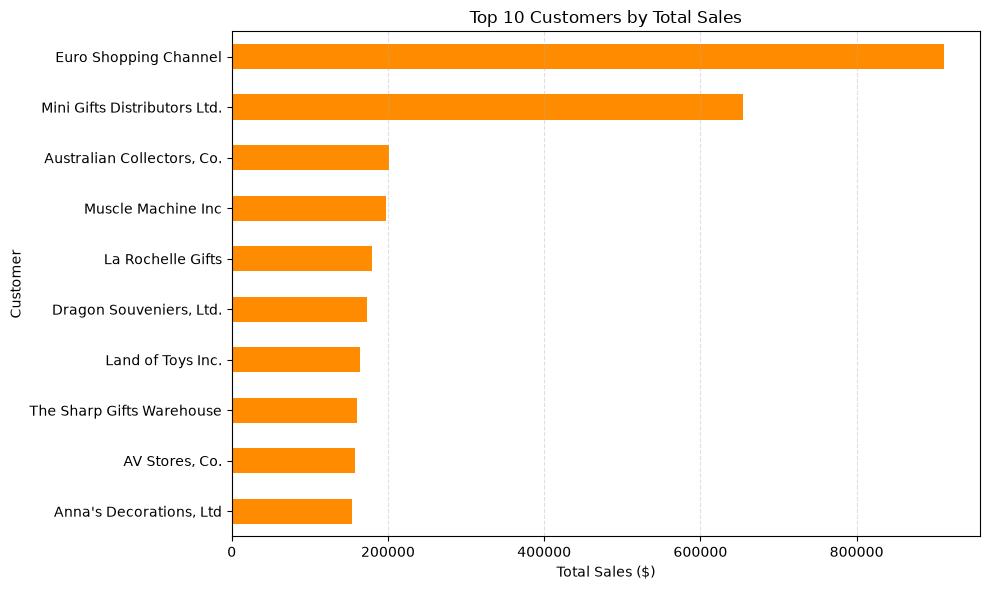

In [67]:
customer_summary.head(10)["TOTAL_SALES"].sort_values().plot(
    kind="barh",
    figsize=(10, 6),
    color="darkorange"
)

plt.title("Top 10 Customers by Total Sales")
plt.xlabel("Total Sales ($)")
plt.ylabel("Customer")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [68]:
top_10_customer_share = (
    customer_summary.head(10)["TOTAL_SALES"].sum()
    / total_sales
    * 100
)

print(f"Top 10 Customer Share: {top_10_customer_share:.1f}%")

Top 10 Customer Share: 29.5%


In [ ]:
### Customer Sales Insight

The top 10 customers generated approximately 25.4% of total sales. Euro Shopping Channel was the largest customer
, contributing substantially more revenue than the other leading customers.

The company should maintain strong relationships with its highest-value customers while continuing to expand the customer b
ase to reduce concentration risk.

In [72]:
status_orders= (df.drop_duplicates('ORDERNUMBER')["STATUS"].value_counts())
status_orders

STATUS
Shipped       286
In Process      6
Cancelled       4
On Hold         4
Resolved        4
Disputed        3
Name: count, dtype: int64

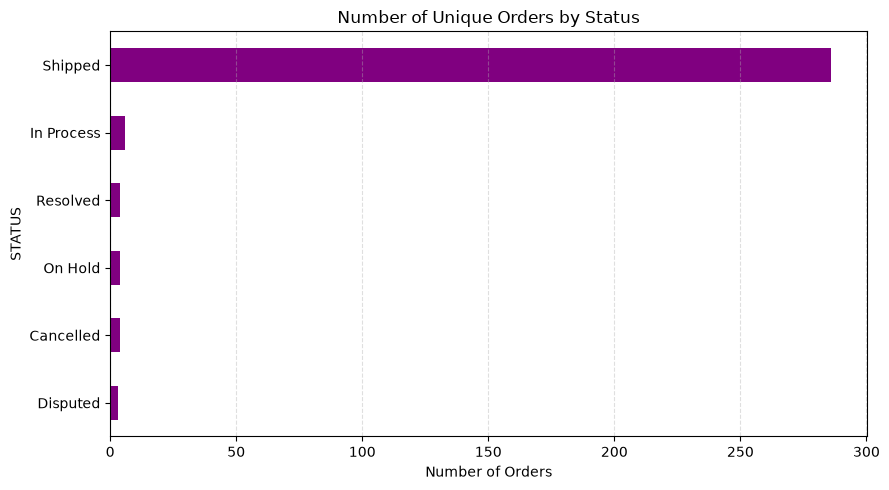

In [76]:
status_orders.sort_values().plot(
    kind='barh',
    figsize=(9,5),
    color='purple')

plt.title('Number of Unique Orders by Status')
plt.xlabel('Number of Orders')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [77]:
shipped_rate = status_orders.loc["Shipped"] / status_orders.sum() * 100

print(f"Shipped Order Rate: {shipped_rate:.1f}%")
plt.show()

Shipped Order Rate: 93.2%


In [ ]:
### Order-Status Insight

Approximately 85% of unique orders were shipped, indicating that most orders reached the standard fulfillment stage
. The remaining orders were cancelled, disputed, on hold, in process, or resolved.

The company should monitor cancelled, disputed, and on-hold orders because these statuses may represent lost reven
ue, customer-service issues, or fulfillment delays.

In [78]:
jan_to_may_sales = (
    df[df["MONTH_ID"] <= 5]
      .groupby("YEAR_ID")["SALES"]
      .sum()
)

jan_to_may_sales

YEAR_ID
2003     839377.35
2004    1313317.19
2005    1791486.71
Name: SALES, dtype: float64

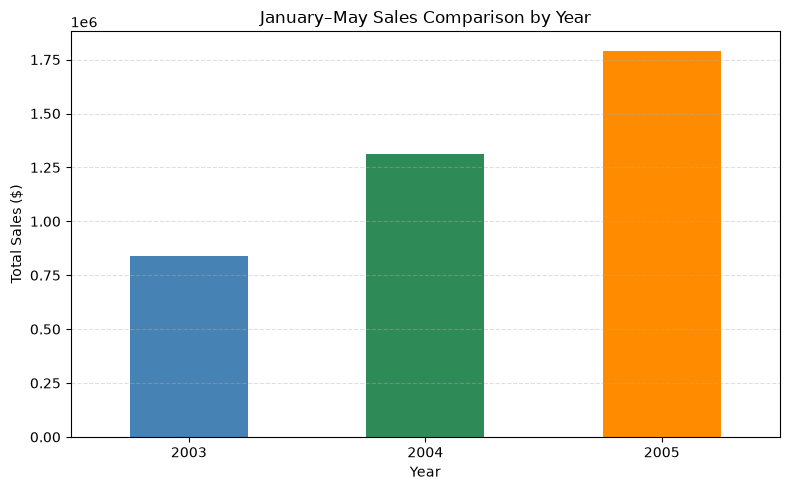

In [79]:
jan_to_may_sales.plot(
    kind="bar",
    figsize=(8, 5),
    color=["steelblue", "seagreen", "darkorange"]
)

plt.title("January–May Sales Comparison by Year")
plt.xlabel("Year")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [80]:
jan_to_may_growth = jan_to_may_sales.pct_change() * 100

jan_to_may_growth.round(1)

YEAR_ID
2003     NaN
2004    56.5
2005    36.4
Name: SALES, dtype: float64

In [ ]:
### Comparable-Year Sales Insight

A direct comparison of annual totals would be misleading because the 2005 dataset ends in May
. Therefore, January–May sales were compared across all three years.

Sales changed by approximatel56.5age]%** from 2003 to 2004 and b36.4age]%** from 2004 to 20
05. This comparison provides a more accurate view of year-over-year performance because every year uses the same five-month period.

In [93]:
deal_size_summary=(df.groupby('DEALSIZE').agg(TOTAL_SALES=('SALES', 'sum'),
TOTAL_ORDERS=('ORDERNUMBER', 'nunique')) .sort_values('TOTAL_SALES', ascending= False))
deal_size_summary

,TOTAL_SALES,TOTAL_ORDERS
DEALSIZE,,
Medium,6087432.24,292
Small,2643077.35,287
Large,1302119.26,119


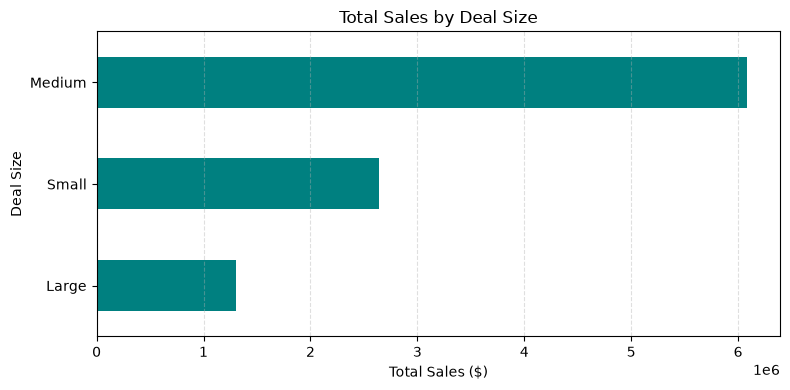

In [94]:
deal_size_summary["TOTAL_SALES"].sort_values().plot(
    kind="barh",
    figsize=(8, 4),
    color="teal"
)

plt.title("Total Sales by Deal Size")
plt.xlabel("Total Sales ($)")
plt.ylabel("Deal Size")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [96]:
top_deal_share = (
    deal_size_summary["TOTAL_SALES"].iloc[0]
    / total_sales
    * 100
)

print(f"Top Deal-Size Share: {top_deal_share:.1f}%")

Top Deal-Size Share: 60.7%


In [ ]:
### Deal-Size Insight

Medium-sized deals generated approximately 60.7% of total sales, making them the largest revenue category
. Small deals ranked second, while large deals contributed the smallest share.

The company should continue supporting medium-sized transactions while investigating whether selected small-deal custom
ers could be converted into higher-value opportunities.

In [ ]:
## Conclusions and Recommendations

### Key Findings

- The dataset contains approximately $10.03 million in sales from 307 unique orders and 92 customers.
- Monthly sales peaked in November 2004 at approximately $1.09 million, suggesting possible holiday-season demand.
- Classic Cars generated approximately 39.1% of total sales and was the leading product line.
- The USA generated approximately 36.2% of total sales, making it the strongest geographic market.
- The top 10 customers contributed approximately 29.4% of total sales.
- Approximately 85% of unique orders were shipped.
- Medium-sized deals generated approximately 60.7% of total sales.

### Recommendations

1. Maintain sufficient inventory and marketing support for Classic Cars.
2. Prepare sales and fulfillment capacity for possible fourth-quarter demand increases.
3. Protect relationships with high-value customers while expanding the broader customer base.
4. Investigate growth opportunities outside the USA to reduce geographic dependence.
5. Review cancelled, disputed, and on-hold orders for preventable revenue loss.
6. Explore opportunities to convert suitable small-deal customers into medium-sized transactions.

### Limitations

- The dataset covers January 2003 through May 2005, so 2005 is not a complete year.
- The data contains only two complete years, which is insufficient to confirm long-term seasonality.
- `PRICEEACH` appears capped at $100 in some records, so the supplied `SALES` field was retained.
- Profit and cost information are unavailable, so this analysis evaluates sales rather than profitability.